# Tilbury tuning-law fits

Load a random Blender-VR imaging session, run `TilburyFitConfig.process`, and inspect the per-neuron fits.

Each neuron is fit (train split) to a sum of up to two asymmetric generalized-Gaussian peaks; 1-vs-2 peaks chosen on validation, R² reported on test.

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from syd import Viewer

from vrAnalysis.database import get_database
from vrAnalysis.helpers import edge2center
from vrAnalysis.processors import SpkmapProcessor
from dimensionality_manuscript.configs import get_data_config
from dimensionality_manuscript.registry import PopulationRegistry
from dimensionality_manuscript import ResultsStore, ResultsAggregator
from dimensionality_manuscript.configs.tilbury_fit import TilburyFitConfig, _eval_tilbury, _eval_gaussian
from dimensionality_manuscript import average_by_mouse

plt.rcParams["font.size"] = 14

sessiondb = get_database("vrSessions")
registry = PopulationRegistry(registry_params=get_data_config("even").to_registry_params())

In [3]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
cfg = TilburyFitConfig()
results = ResultsAggregator(cfg, store, sessions)

In [4]:
def xvals(x):
    return np.arange(x.shape[1]) + 1

class TilburyFitViewer(Viewer):
    def __init__(self, results: ResultsAggregator):
        self = cfg.build_syd(self, results)
        self.update_selection("view_by", value="session")
        self.add_integer("num_bins", value=80, min=5, max=100)

        preferred_state = {
            # "smooth_width": 5.0,
            # "activity_parameters_name": "default",
        }
        for key, value in preferred_state.items():
            self.update_selection(key, value=value)

    def plot(self, state: dict):
        result, axes_names = self.get_result(state)
        idx_p1_1peak = cfg.param_names_1peak.index("p1")
        p1_1peak = result["params_1peak"][..., idx_p1_1peak]

        # Do KDE smoothing for each session's neurons
        edges = np.linspace(0.5, 8.0, state["num_bins"] + 1)
        centers = edge2center(edges)
        density = np.full((p1_1peak.shape[0], len(centers)), np.nan)
        for i, row in enumerate(p1_1peak):
            row = row[np.isfinite(row)]
            if len(row) < 2: 
                continue
            kde = gaussian_kde(row)
            density[i] = kde(centers)

        # Density by mouse
        mouse_density = average_by_mouse(density, results.mouse_names)
        
        # Plot density
        fig, ax = plt.subplots(1, 1, figsize=(4, 4), layout="constrained")
        ax.plot(centers, mouse_density.T)
        ax.set_xlabel("Peak Exponent")
        ax.set_ylabel("Density")
        ax.set_title("Peak Exponent Density by Mouse")
    
        return fig

viewer = TilburyFitViewer(results)
# viewer.show()

## Pick a random session

In [29]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
print(f"{len(sessions)} Blender-VR imaging sessions")

rng = np.random.default_rng()
# session = sessions[rng.integers(len(sessions))]
session = sessions[41]
print(session)
print("Environments:", session.environments)
for env in session.environments:
    print("  env", env, "num_trials:", int(np.sum(session.trial_environment == env)))

140 Blender-VR imaging sessions
B2Session(mouse_name='ATL022', date='2023-04-21', session_id='701', spks_type='significant')
Environments: [1 3]
  env 1 num_trials: 49
  env 3 num_trials: 52


## Run the fit

In [46]:
cfg = TilburyFitConfig(
    spks_type="sigrebase",
    num_bins=100,
    reliability_fraction_active_thresholds=(0.5, 0.1),
)
print(cfg.summary())

result = cfg.process(session, registry, verbose=True, device="cuda", gd_learning_rate=0.1, gd_num_steps=4000)

for k, v in result.items():
    shape = getattr(v, "shape", v)
    print(f"{k:16s}: {shape}")

tilbury_fit_spks=sigrebase_ap=raw_bins=100_rel=0.5_frac=0.1_v2


descent fit control: 100%|██████████| 4000/4000 [00:07<00:00, 518.48it/s, loss=1.66e+05] 


params          : (1319, 6)
r2_train        : (1319,)
r2_val          : (1319,)
r2_test         : (1319,)
params_control  : (1319, 4)
r2_train_control: (1319,)
r2_val_control  : (1319,)
r2_test_control : (1319,)
idx_keep        : (8562,)
dist_centers    : (99,)
best_env        : ()
param_names     : ['b', 'A', 'phi', 'sigma_left', 'sigma_right', 'p']
param_names_control: ['b', 'A', 'phi', 'sigma']


In [ ]:
population, frame_behavior = registry.get_population(session, cfg.spks_type)
spkmap = SpkmapProcessor(session)
reliability = (
    spkmap.get_reliability(use_session_filters=False)
    .filter_rois(population.idx_neurons)
    .filter_rois(result["idx_keep"])
    .filter_by_environment([result["best_env"]])
)
best_env_reliability = reliability.values[0]

## Summary stats

In [39]:
# Least squares stats
r2_test = result["r2_test"]
r2_test_control = result["r2_test_control"]

print(f"Neurons kept       : {result['idx_keep'].sum()} / {result['idx_keep'].shape[0]}")
print(f"Best environment   : {result['best_env']}")
print(f"Position bins used : {result['dist_centers'].shape[0]}")
print(f"median test R2     : {np.nanmedian(r2_test):.3f}")
print(f"frac test R2 > 0.5 : {np.nanmean(r2_test > 0.5):.3f}")
print(f"frac test R2 > 0.0 : {np.nanmean(r2_test > 0.0):.3f}")
print(f"CTL: median test R2     : {np.nanmedian(r2_test_control):.3f}")
print(f"CTL: frac test R2 > 0.5 : {np.nanmean(r2_test_control > 0.5):.3f}")
print(f"CTL: frac test R2 > 0.0 : {np.nanmean(r2_test_control > 0.0):.3f}")

Neurons kept       : 1319 / 8562
Best environment   : 3
Position bins used : 99
median test R2     : 0.522
frac test R2 > 0.5 : 0.515
frac test R2 > 0.0 : 0.718
CTL: median test R2     : 0.521
CTL: frac test R2 > 0.5 : 0.515
CTL: frac test R2 > 0.0 : 0.716


0.46324655436447165


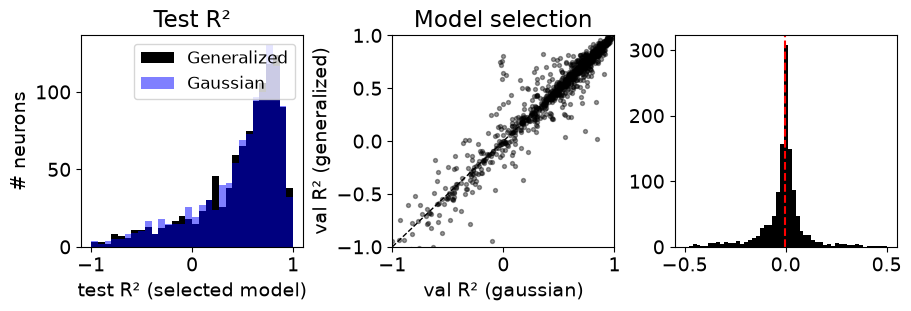

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3), layout="constrained")

axs[0].hist(r2_test[np.isfinite(r2_test)], bins=30, range=(-1.0, 1), label="Generalized", color="black")
axs[0].hist(r2_test_control[np.isfinite(r2_test_control)], bins=30, range=(-1.0, 1), label="Gaussian", color=("blue", 0.5))
axs[0].set(xlabel="test R² (selected model)", ylabel="# neurons", title="Test R²")
axs[0].legend(loc="upper right", fontsize=12)

axs[1].scatter(r2_test_control, r2_test, s=8, alpha=0.4, color="black")
axs[1].plot([-1.0, 1], [-1.0, 1], "k--", lw=1)
axs[1].set(xlabel="val R² (gaussian)", ylabel="val R² (generalized)", title="Model selection", xlim=(-1.0, 1), ylim=(-1.0, 1))

idx_valid = np.logical_and(np.isfinite(r2_test), np.isfinite(r2_test_control))
r2_improvement = r2_test[idx_valid] - r2_test_control[idx_valid]
print(np.sum(r2_improvement > 0) / len(r2_improvement))
axs[2].hist(r2_improvement, bins=51, range=(-0.5, 0.5), color="black")
axs[2].axvline(np.median(r2_improvement), color="r", linestyle="--", linewidth=1.5)
plt.show()

## Example fits overlaid on the test placefield

Re-derive the test-split averaged placefield (via the config's own helpers) to overlay data vs fitted model for the best-fit neurons.

In [41]:
# Rebuild the test-split curve on the same bins the fit used.
theta = result["dist_centers"]
best_env = result["best_env"]
dist_edges = np.linspace(0, session.env_length[0], cfg.num_bins + 1)
good = np.isin(edge2center(dist_edges), theta)

spks, fb = cfg._get_split_data(session, registry)
for s in spks:
    spks[s] = spks[s][:, result["idx_keep"]]

test_curve_full, _ = cfg._avg_placefield(spks["test"], fb["test"], dist_edges, best_env, session)
test_curve = test_curve_full[:, good]
print("test_curve shape:", test_curve.shape)

test_curve shape: (1319, 99)


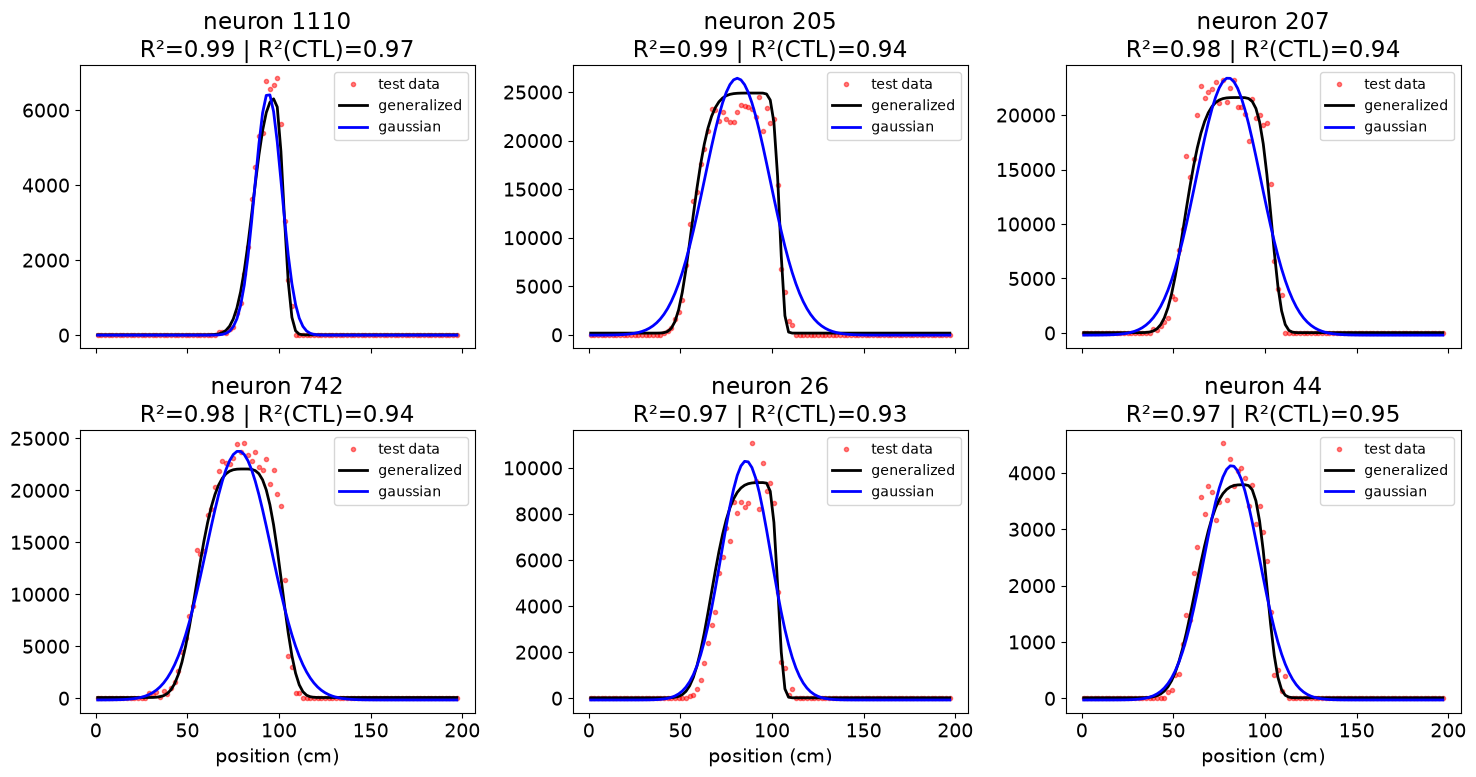

In [42]:
# Top 6 neurons by test R2.
order = np.argsort(np.nan_to_num(r2_test, nan=-np.inf))[::-1][:6]

fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, n in zip(axs.flat, order):
    params = result["params"][n]
    fitted = _eval_tilbury(theta, params)
    params_control = result["params_control"][n]
    fitted_control = _eval_gaussian(theta, params_control, )
    ax.plot(theta, test_curve[n], "ro", ms=3, alpha=0.5, label="test data")
    ax.plot(theta, fitted, "k-", lw=2, label=f"generalized")
    ax.plot(theta, fitted_control, "b-", lw=2, label=f"gaussian")
    ax.set_title(f"neuron {n}\nR²={r2_test[n]:.2f} | R²(CTL)={r2_test_control[n]:.2f}")
    ax.legend(fontsize=10)
for ax in axs[-1]:
    ax.set_xlabel("position (cm)")
fig.tight_layout()
plt.show()

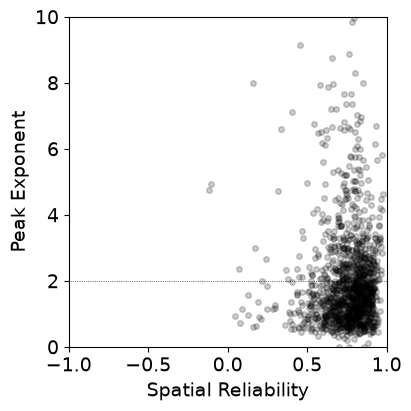

In [43]:
alpha = 0.2
line_params = lambda color, alpha, label: {
    "color": (color, alpha), 
    "linestyle": "none",
    "marker": ".",
    "markersize": 8,
    "label": label,
}
plt.close('all')
fig, ax = plt.subplots(1, 1, figsize=(4, 4), layout="constrained", sharex="col", sharey=True)
ax.plot(best_env_reliability, result["params"][:, 5], **line_params("black", alpha, None))
ax.set_xlabel("Spatial Reliability")
ax.set_ylabel("Peak Exponent")

ax.set_xlim(-1, 1)
ax.set_ylim(0, 10)
ax.axhline(y=2.0, color="k", linestyle=":", linewidth=0.5)
plt.show()

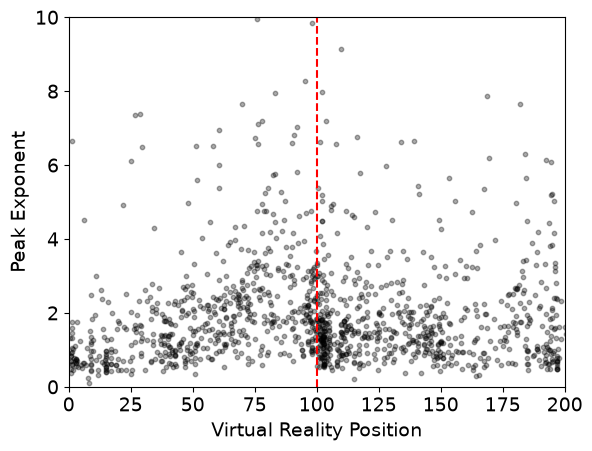

In [44]:
# Compare peakiness probability to location (relative to placefield!)
environmentIndex = session.loadone("trials.environmentIndex")
rewardPosition = session.loadone("trials.rewardPosition")
rewardTolerance = session.loadone("trials.rewardZoneHalfwidth")
env_to_reward = {e: r - t for e, r, t in zip(environmentIndex, rewardPosition, rewardTolerance)}
unique_env_to_reward = dict(set(env_to_reward.items()))

idx_peak1 = result["param_names"].index("phi")
idx_p1 = result["param_names"].index("p")
plt.close('all')
plt.scatter(result["params"][:, idx_peak1], result["params"][:, idx_p1], s=10, c="k", alpha=0.33)
plt.axvline(x=unique_env_to_reward[result["best_env"]], color="red", linestyle="--")
plt.xlabel("Virtual Reality Position")
plt.ylabel("Peak Exponent")
plt.xlim(0, session.env_length[0])
plt.ylim(0, 10)
plt.show()

In [47]:
class PlacefieldFitViewer(Viewer):
    def __init__(self, result_ls: dict, result_gd: dict):
        self.result_ls = result_ls
        self.result_gd = result_gd

        # Rebuild the test-split curve on the same bins the fit used.
        self.theta = result_ls["dist_centers"]
        best_env = result_ls["best_env"]
        dist_edges = np.linspace(0, session.env_length[0], cfg.num_bins + 1)
        good = np.isin(edge2center(dist_edges), self.theta)

        spks, fb = cfg._get_split_data(session, registry)
        for s in spks:
            spks[s] = spks[s][:, result_ls["idx_keep"]]

        train_curve_full, _ = cfg._avg_placefield(spks["train"], fb["train"], dist_edges, best_env, session)
        test_curve_full, _ = cfg._avg_placefield(spks["test"], fb["test"], dist_edges, best_env, session)
        self.train_curve = train_curve_full[:, good]
        self.test_curve = test_curve_full[:, good]

        self.add_selection("peak_mode", options=["1peak", "2peak"])
        self.add_selection("sort_by", options=["p1", "r2", "delta"])
        self.add_selection("use_mode", options=["least-squares", "descent"])
        self.add_integer("idx_neuron", min=0, max=self.train_curve.shape[0] - 1)

        idx_p1_1peak = self.result_ls["params_1peak_names"].index("p1")
        idx_p1_2peak = self.result_ls["params_2peak_names"].index("p1")
        self.p1_1peak_ls = self.result_ls["params_1peak"][:, idx_p1_1peak]
        self.p1_2peak_ls = self.result_ls["params_2peak"][:, idx_p1_2peak]
        self.r2_1peak_ls = self.result_ls["r2_test_1"]
        self.r2_2peak_ls = self.result_ls["r2_test_2"]
        self.r2_1peak_control_ls = self.result_ls["r2_test_1_control"]
        self.r2_2peak_control_ls = self.result_ls["r2_test_2_control"]
        self.p1_1peak_gd = self.result_gd["params_1peak"][:, idx_p1_1peak]
        self.p1_2peak_gd = self.result_gd["params_2peak"][:, idx_p1_2peak]
        self.r2_1peak_gd = self.result_gd["r2_test_1"]
        self.r2_2peak_gd = self.result_gd["r2_test_2"]
        self.r2_1peak_control_gd = self.result_gd["r2_test_1_control"]
        self.r2_2peak_control_gd = self.result_gd["r2_test_2_control"]

        self.val_lookups = {
            "least-squares_p1_1peak": self.p1_1peak_ls,
            "least-squares_p1_2peak": self.p1_2peak_ls,
            "least-squares_r2_1peak": self.r2_1peak_ls,
            "least-squares_r2_2peak": self.r2_2peak_ls,
            "least-squares_delta_1peak": self.r2_1peak_ls - self.r2_1peak_control_ls,
            "least-squares_delta_2peak": self.r2_2peak_ls - self.r2_2peak_control_ls,
            "descent_p1_1peak": self.p1_1peak_gd,
            "descent_p1_2peak": self.p1_2peak_gd,
            "descent_r2_1peak": self.r2_1peak_gd,
            "descent_r2_2peak": self.r2_2peak_gd,
            "descent_delta_1peak": self.r2_1peak_gd - self.r2_1peak_control_gd,
            "descent_delta_2peak": self.r2_2peak_gd - self.r2_2peak_control_gd,
        }

    def plot(self, state):
        lookup_key = "_".join([state["use_mode"], state["sort_by"], state["peak_mode"]])
        val_for_sort = self.val_lookups[lookup_key]

        num_peaks = int(state["peak_mode"][0])

        idx_sort = np.argsort(val_for_sort)
        idx = idx_sort[state["idx_neuron"]]
        train = self.train_curve[idx]
        test = self.test_curve[idx]
        if state["use_mode"] == "least-squares":
            params = self.result_ls[f"params_{state['peak_mode']}"][idx]
        else:
            params = self.result_gd[f"params_{state['peak_mode']}"][idx]
        fitted =_eval_tilbury(self.theta, params, num_peaks)

        fig, ax = plt.subplots(1, 1, figsize=(4, 4), layout="constrained")
        ax.plot(self.theta, train, "ko", ms=3, alpha=0.5, label="train")
        ax.plot(self.theta, test, "ro", ms=3, alpha=0.5, label="test")
        ax.plot(self.theta, fitted, "b-", lw=1.0, label="Fit")
        return fig

viewer = PlacefieldFitViewer(result_ls, result_gd)
viewer.show()